In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import numpy as np
import folium

In [3]:
# --- Etapa 1: Carrega e Prepara os Dados de Treinamento ---

print("--- Iniciando Etapa 1: Preparação dos Dados para Regressão ---")
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/FACT_LOCALIDADE_CLIMA_202509272358.csv')

# Passando os nomes das colunas para minúsculas (lowercase)
df_train.columns = [col.replace('"', '').lower() for col in df_train.columns]

# Remove dados faltantes (NaN)
print("\nLimpando dados faltantes no arquivo de treino...")
df_train.dropna(inplace=True)
print("Limpeza do arquivo de treino concluída.")


--- Iniciando Etapa 1: Preparação dos Dados para Regressão ---

Limpando dados faltantes no arquivo de treino...
Limpeza do arquivo de treino concluída.


In [4]:
# --- Etapa 2: Treinamento do Modelo de Regressão ---

print("\n--- Iniciando Etapa 2: Treinamento do Modelo de Regressão ---")

# Aqui foi definida a variável alvo e as variáveis de entrada (features)
target = 'shortwave_radiation_sum'
features = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'relative_humidity_2m_mean', 'surface_pressure_mean', 'wind_speed_10m_max',
    'wind_speed_10m_mean', 'precipitation_sum'
]

# Features que serão usadas
print("\nFeatures que serão usadas no modelo:")
print(features)

X = df_train[features]
y = df_train[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nIniciando o treinamento do modelo...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Treinamento concluído.")

# Avaliação da performance do modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nResultados da Avaliação do Modelo:")
print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"MSE (Erro Quadrático Médio): {mse:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {np.sqrt(mse):.4f}")



--- Iniciando Etapa 2: Treinamento do Modelo de Regressão ---

Features que serão usadas no modelo:
['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'relative_humidity_2m_mean', 'surface_pressure_mean', 'wind_speed_10m_max', 'wind_speed_10m_mean', 'precipitation_sum']

Iniciando o treinamento do modelo...
Treinamento concluído.

Resultados da Avaliação do Modelo:
R² (Coeficiente de Determinação): 0.7281
MSE (Erro Quadrático Médio): 4.5627
RMSE (Raiz do Erro Quadrático Médio): 2.1360


In [5]:
# --- Etapa 3: Salva o Modelo Treinado ---

print("\n--- Iniciando Etapa 3: Salvando o Modelo de Regressão ---")
model_filename = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/random_forest_regressor_solar.joblib'
joblib.dump(model, model_filename)
print(f"Modelo salvo com sucesso no arquivo: {model_filename}")




--- Iniciando Etapa 3: Salvando o Modelo de Regressão ---
Modelo salvo com sucesso no arquivo: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/random_forest_regressor_solar.joblib


In [12]:
# --- Etapa 4: Usando o Modelo para Prever o Potencial Solar ---

print("\n--- Iniciando Etapa 4: Prevendo a Radiação Solar para Goiás ---")
df_goias = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/goias_clima_era5_diario_completo.csv')

# Limpeza de dados faltantes no arquivo de Goiás, se houvercaso existam
if df_goias[features].isnull().sum().any():
    print("\nAlerta: Encontrados valores NaN nos dados de Goiás. Removendo as linhas correspondentes.")
    df_goias.dropna(subset=features, inplace=True)

X_goias = df_goias[features]
loaded_model = joblib.load(model_filename)
print(f"\nModelo '{model_filename}' carregado com sucesso.")

goias_solar_predictions = loaded_model.predict(X_goias)
df_goias['RADIACAO_SOLAR_PREDITA'] = goias_solar_predictions

print("\nPrevisões de Radiação Solar para Goiás (MJ/m²):")
print(df_goias[['municipio', 'time', 'RADIACAO_SOLAR_PREDITA']].head())

# Definindo o nome do arquivo final com as previsões
results_filename = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/previsoes_radiacao_solar_goias.csv'
df_goias.to_csv(results_filename, index=False)
print(f"\nResultados das previsões salvos com sucesso em: {results_filename}")


--- Iniciando Etapa 4: Prevendo a Radiação Solar para Goiás ---

Alerta: Encontrados valores NaN nos dados de Goiás. Removendo as linhas correspondentes.

Modelo '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/random_forest_regressor_solar.joblib' carregado com sucesso.

Previsões de Radiação Solar para Goiás (MJ/m²):
         municipio        time  RADIACAO_SOLAR_PREDITA
0  Abadia de Goiás  2025-01-01                 23.7560
1  Abadia de Goiás  2025-01-02                 20.8994
2  Abadia de Goiás  2025-01-03                 24.2848
3  Abadia de Goiás  2025-01-04                 22.1984
4  Abadia de Goiás  2025-01-05                 23.0175

Resultados das previsões salvos com sucesso em: /content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/previsoes_radiacao_solar_goias.csv


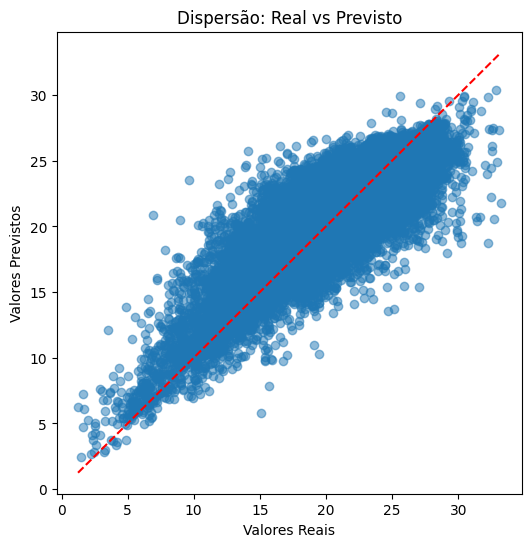

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Dispersão: Real vs Previsto')
plt.show()

In [7]:
# --- Etapa 5: Carregando arquivo com as previsões ---

print("--- Carregando o arquivo com as previsões ---")
try:
    df_previsoes = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/previsoes_radiacao_solar_goias.csv')
    print("Arquivo 'previsoes_radiacao_solar_goias.csv' carregado com sucesso.")
except FileNotFoundError:
    print("Erro: O arquivo 'previsoes_radiacao_solar_goias.csv' não foi encontrado.")
    print("Por favor, execute o script anterior para gerar este arquivo ou verifique o caminho.")
    exit()

--- Carregando o arquivo com as previsões ---
Arquivo 'previsoes_radiacao_solar_goias.csv' carregado com sucesso.


In [8]:
# --- Etapa 6: Calculando a Média de Radiação por Município ---

print("\n--- Calculando o potencial solar médio por município ---")
# Aqui os dados são agrupados por município. Para cada um, é calculada a média da radiação solar.
# Também pegamos a primeira latitude e longitude, já que elas são constantes para cada município.
potencial_solar = df_previsoes.groupby('municipio').agg(
    radiacao_media=('RADIACAO_SOLAR_PREDITA', 'mean'),
    lat=('lat', 'first'),
    lon=('lon', 'first')
).reset_index()


--- Calculando o potencial solar médio por município ---


In [9]:
# --- Etapa 7: Seleciona os Municípios com Maior Potencial ---

print("--- Selecionando os municípios com maior irradiação ---")
# Ordenamos o resultado pela 'radiacao_media' em ordem decrescente e pegamos os 10 primeiros.
top_municipios = potencial_solar.sort_values(by='radiacao_media', ascending=False).head(10)

print("\nOs 10 municípios com maior potencial solar médio (MJ/m²):")
print(top_municipios.head(10))


--- Selecionando os municípios com maior irradiação ---

Os 10 municípios com maior potencial solar médio (MJ/m²):
                 municipio  radiacao_media        lat        lon
142  Monte Alegre de Goiás       21.360359 -13.294168 -46.923046
133                 Mambaí       21.301882 -14.411867 -46.067983
72            Damianópolis       21.161473 -14.555617 -46.190635
50            Campos Belos       21.138211 -12.999860 -46.514428
214           São Domingos       21.092709 -13.536476 -46.486560
226      Teresina de Goiás       21.087211 -13.681895 -47.237195
84         Flores de Goiás       21.015166 -14.651360 -46.904229
224         Sítio d'Abadia       20.997634 -14.713935 -46.204806
8        Alvorada do Norte       20.977862 -14.566064 -46.631254
160              Nova Roma       20.959955 -13.800260 -47.010427


In [10]:
# --- Etapa 8: Gera o Mapa Interativo com Folium ---

print("\n--- Gerando o mapa interativo ---")
# Cria um mapa centrado nas coordenadas aproximadas de Goiás. Onde latitude e longitude de Goiás: -15.98, -49.86
mapa_goias = folium.Map(location=[-15.98, -49.86], zoom_start=7, tiles='OpenStreetMap')

# Adiciona um marcador para cada um dos municípios mais relevantes
for index, row in top_municipios.iterrows():
    # Coordenadas do município
    location = [row['lat'], row['lon']]

    # Texto para o pop-up do marcador
    popup_text = f"""
    <b>Município:</b> {row['municipio']}<br>
    <b>Radiação Média:</b> {row['radiacao_media']:.2f} MJ/m²
    """

    # Cria o marcador e o adiciona ao mapa
    folium.Marker(
        text=row['municipio'],
        permanent=True,
        location=location,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=row['municipio']
    ).add_to(mapa_goias)

# Salva o mapa como um arquivo HTML
mapa_filename = '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/mapa_potencial_solar_goias.html'
mapa_goias.save(mapa_filename)
print(f"\nMapa salvo com sucesso em '{mapa_filename}'.")

mapa_goias


--- Gerando o mapa interativo ---

Mapa salvo com sucesso em '/content/drive/MyDrive/Colab Notebooks/pos-ifg/trabalho_modulo_2/6.random_forest/arquivos_gerados/mapa_potencial_solar_goias.html'.
